# Exploratory Data Analysis
**Dataset:** UCI Online Retail II (cleaned)  
**Goal:** Understand the data through numbers and charts before building any models.  
**Rule:** Run cells top to bottom. Reading every comment explains the *why*, alongside the *what*.

## Cell 1 — Imports and settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Plot style — applies to all charts in this notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})
BLUE   = '#185FA5'   # main chart colour
TEAL   = '#0F6E56'   # secondary chart colour
AMBER  = '#854F0B'   # accent colour

# Paths — adjust if your folder structure is different
ROOT     = Path('..').resolve()   # project root (one level up from notebooks/)
DATA_DIR = ROOT / 'data'
RPT_DIR  = ROOT / 'reports'
RPT_DIR.mkdir(exist_ok=True)      # create reports/ if it doesn't exist yet

print('Imports done. Paths set.')
print(f'Data dir : {DATA_DIR}')
print(f'Reports  : {RPT_DIR}')

Imports done. Paths set.
Data dir : C:\Users\aishw\Documents\customer_segmentation\data
Reports  : C:\Users\aishw\Documents\customer_segmentation\reports


In [2]:
#pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -----------------------------------

## Cell 2 — Load clean data

In [2]:
# We load the CLEAN CSV (produced by src/ingest.py), not the raw Excel.
# CSV loads in ~2 seconds vs ~60 seconds for Excel.
df = pd.read_csv(DATA_DIR / 'clean_retail.csv', parse_dates=['InvoiceDate'])

print(f'Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns : {list(df.columns)}')
print()
df.head(3)

Shape   : 779,425 rows × 15 columns
Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice', 'YearMonth', 'Year', 'Month', 'DayOfWeek', 'Hour', 'Date']



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,YearMonth,Year,Month,DayOfWeek,Hour,Date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009,12,Tuesday,7,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009,12,Tuesday,7,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009,12,Tuesday,7,2009-12-01


## Cell 3 — Quick health check

In [4]:
df = df.rename(columns={'Customer ID': 'CustomerID'})

In [5]:
# ── Null check ──────────────────────────────────────────────
# After cleaning, nulls should be zero (or very close to it).
# If you see high null counts here, re-run src/ingest.py.
print('--- Null counts after cleaning ---')
print(df.isnull().sum())
print()

# ── Data types ──────────────────────────────────────────────
print('--- Data types ---')
print(df.dtypes)
print()

# ── Date range ──────────────────────────────────────────────
print(f'Date range : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

--- Null counts after cleaning ---
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
TotalPrice     0
YearMonth      0
Year           0
Month          0
DayOfWeek      0
Hour           0
Date           0
dtype: int64

--- Data types ---
Invoice                 int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID              int64
Country                object
TotalPrice            float64
YearMonth              object
Year                    int64
Month                   int64
DayOfWeek              object
Hour                    int64
Date                   object
dtype: object

Date range : 2009-12-01 → 2011-12-09


In [7]:
df["Invoice"] = df["Invoice"].astype(str)
df["CustomerID"] = df["CustomerID"].astype(str)
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID             object
Country                object
TotalPrice            float64
YearMonth              object
Year                    int64
Month                   int64
DayOfWeek              object
Hour                    int64
Date                   object
dtype: object


## Cell 4 — Summary statistics

In [9]:
# describe() shows count, mean, min, max, and percentiles.
# Look at TotalPrice and Quantity — do the ranges make sense?
# A max TotalPrice of several thousand is normal for bulk B2B orders.
df[['Quantity', 'Price', 'TotalPrice']].describe().round(4)

,Quantity,Price,TotalPrice
count,779425.0000,779425.0000,779425.0000
mean,13.4894,3.2185,22.2918
std,145.8558,29.6761,227.4271
min,1.0000,0.0010,0.0010
25%,2.0000,1.2500,4.9500
50%,6.0000,1.9500,12.4800
75%,12.0000,3.7500,19.8000
max,80995.0000,10953.5000,168469.6000


In [11]:
# Key business metrics — save these, we'll log them to MLflow at the end
invoice_totals = df.groupby('Invoice')['TotalPrice'].sum()

stats = {
    'total_rows'        : int(len(df)),
    'unique_customers'  : int(df['CustomerID'].nunique()),
    'unique_invoices'   : int(df['Invoice'].nunique()),
    'unique_products'   : int(df['StockCode'].nunique()),
    'unique_countries'  : int(df['Country'].nunique()),
    'total_revenue_gbp' : round(float(df['TotalPrice'].sum()), 2),
    'median_order_value': round(float(invoice_totals.median()), 2),
    'mean_order_value'  : round(float(invoice_totals.mean()), 2),
    'date_start'        : str(df['InvoiceDate'].min().date()),
    'date_end'          : str(df['InvoiceDate'].max().date()),
}

print('Business summary:')
for k, v in stats.items():
    print(f'  {k:<25} : {v}')

Business summary:
  total_rows                : 779425
  unique_customers          : 5878
  unique_invoices           : 36969
  unique_products           : 4631
  unique_countries          : 41
  total_revenue_gbp         : 17374804.27
  median_order_value        : 303.04
  mean_order_value          : 469.98
  date_start                : 2009-12-01
  date_end                  : 2011-12-09


## Cell 5 — Plot 1: Monthly revenue
The first chart any stakeholder would want to see. Does revenue trend up? Are there seasonal spikes?

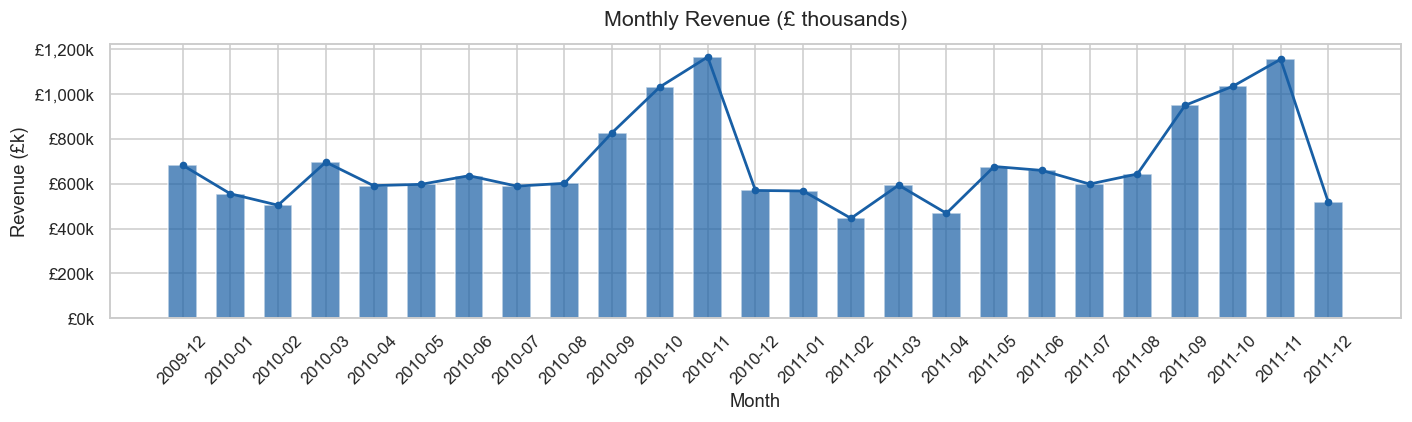

Saved → reports/plot_01_monthly_revenue.png


In [12]:
monthly_rev = (
    df.groupby('YearMonth')['TotalPrice']
      .sum()
      .reset_index()
      .rename(columns={'TotalPrice': 'Revenue'})
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly_rev['YearMonth'], monthly_rev['Revenue'] / 1e3,
       color=BLUE, alpha=0.7, width=0.6, label='Revenue')
ax.plot(monthly_rev['YearMonth'], monthly_rev['Revenue'] / 1e3,
        color=BLUE, linewidth=1.8, marker='o', markersize=4)

ax.set_title('Monthly Revenue (£ thousands)', fontsize=14, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£k)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_01_monthly_revenue.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_01_monthly_revenue.png')

# What to look for:
# - A big spike around Nov-Dec 2011 (Christmas season)
# - General upward trend across the 2 years
# - A dip in early 2011 (post-Christmas slowdown)

## Cell 6 — Plot 2: Top 10 products by revenue
Which products drive the most money? This helps us understand the catalogue before segmenting customers.

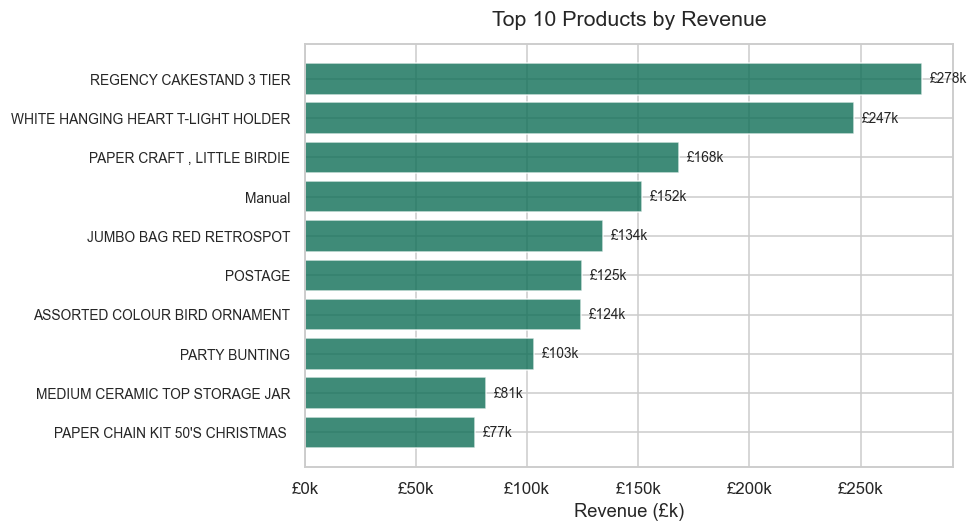

In [13]:
top_products = (
    df.groupby('Description')['TotalPrice']
      .sum()
      .nlargest(10)
      .sort_values()  # sort ascending so the longest bar is at the top
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_products.index, top_products.values / 1e3,
               color=TEAL, alpha=0.8, edgecolor='white')
ax.bar_label(bars,
             labels=[f'£{v/1e3:,.0f}k' for v in top_products.values],
             padding=5, fontsize=9)

ax.set_title('Top 10 Products by Revenue', fontsize=14, pad=12)
ax.set_xlabel('Revenue (£k)')
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_02_top_products.png', bbox_inches='tight')
plt.show()

## Cell 7 — Plot 3: Revenue by country (excl. UK)
The UK dominates — most orders are domestic. But who is buying internationally?

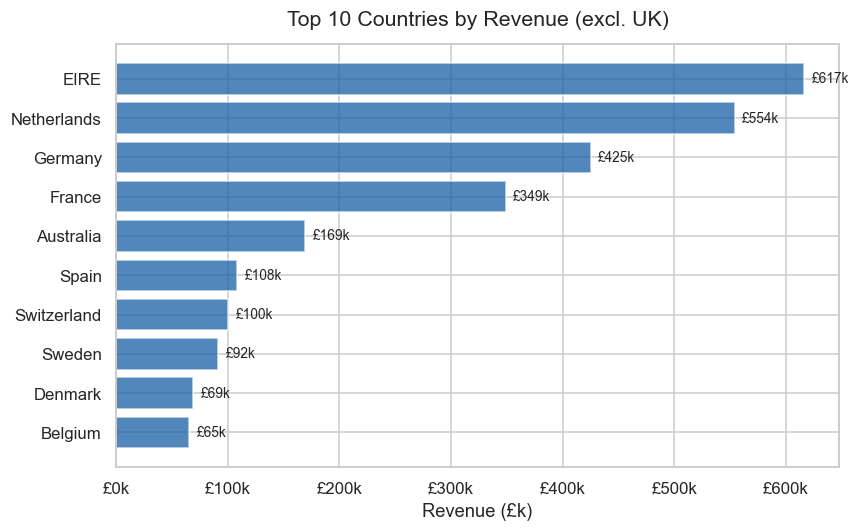

In [14]:
country_rev = (
    df[df['Country'] != 'United Kingdom']  # exclude UK — it dwarfs everyone else
      .groupby('Country')['TotalPrice']
      .sum()
      .nlargest(10)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(country_rev.index, country_rev.values / 1e3,
               color=BLUE, alpha=0.75, edgecolor='white')
ax.bar_label(bars,
             labels=[f'£{v/1e3:,.0f}k' for v in country_rev.values],
             padding=5, fontsize=9)

ax.set_title('Top 10 Countries by Revenue (excl. UK)', fontsize=14, pad=12)
ax.set_xlabel('Revenue (£k)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_03_country_revenue.png', bbox_inches='tight')
plt.show()

## Cell 8 — Plot 4: Orders per customer
How many times does a typical customer buy? This is the 'Frequency' component of RFM.
We expect a heavily right-skewed distribution — most customers buy once or twice.

In [24]:
orders_per_customer = df.groupby('CustomerID')['Invoice'].nunique()
orders_per_customer.quantile(0.99)

np.float64(46.0)

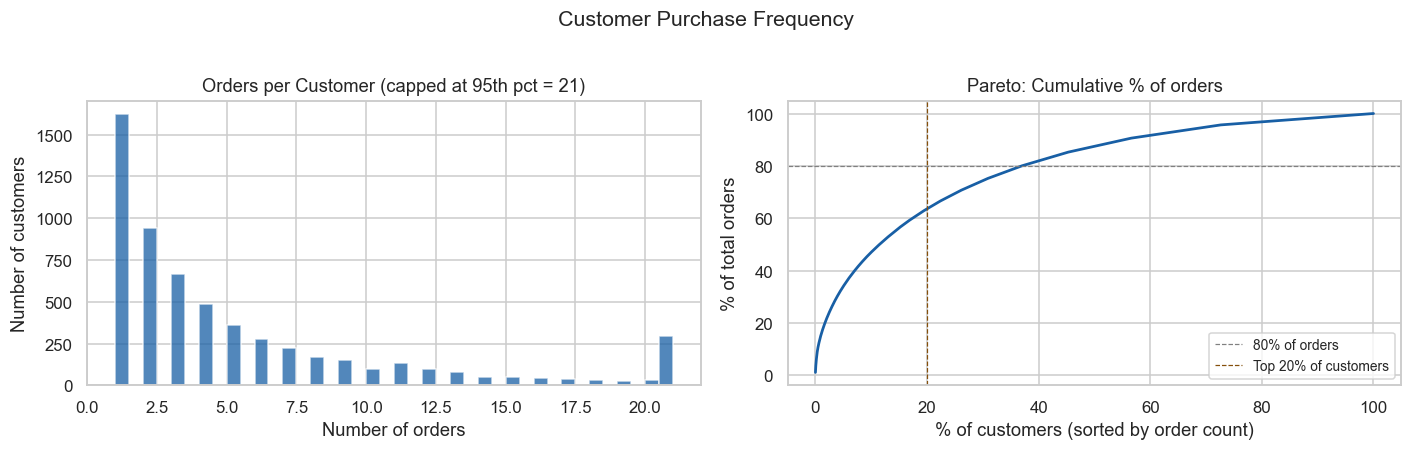

Median orders per customer : 3.0
Mean orders per customer   : 6.3
Max orders by one customer : 398


In [27]:
orders_per_customer = df.groupby('CustomerID')['Invoice'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram (capped at 95th percentile so the tail doesn't squash the chart)
cap = int(orders_per_customer.quantile(0.95))
axes[0].hist(orders_per_customer.clip(upper=cap), bins=40,
             color=BLUE, alpha=0.75, edgecolor='white')
axes[0].set_title(f'Orders per Customer (capped at 95th pct = {cap})')
axes[0].set_xlabel('Number of orders')
axes[0].set_ylabel('Number of customers')

# Right: Pareto curve — what % of customers account for X% of orders?
# The classic 80/20 rule: do 20% of customers drive 80% of orders?
sorted_orders = orders_per_customer.sort_values(ascending=False)
cum_orders    = np.cumsum(sorted_orders) / sorted_orders.sum() * 100
cust_pct      = np.arange(1, len(cum_orders) + 1) / len(cum_orders) * 100

axes[1].plot(cust_pct, cum_orders, color=BLUE, linewidth=1.8)
axes[1].axhline(80, color='gray', linestyle='--', linewidth=0.8, label='80% of orders')
axes[1].axvline(20, color=AMBER, linestyle='--', linewidth=0.8, label='Top 20% of customers')
axes[1].set_title('Pareto: Cumulative % of orders')
axes[1].set_xlabel('% of customers (sorted by order count)')
axes[1].set_ylabel('% of total orders')
axes[1].legend(fontsize=9)

plt.suptitle('Customer Purchase Frequency', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_04_order_frequency.png', bbox_inches='tight')
plt.show()

print(f'Median orders per customer : {orders_per_customer.median():.1f}')
print(f'Mean orders per customer   : {orders_per_customer.mean():.1f}')
print(f'Max orders by one customer : {orders_per_customer.max()}')

## Cell 9 — Plot 5: Average Order Value (AOV) distribution
How much does a typical order cost? High variance here means some customers are bulk B2B buyers.

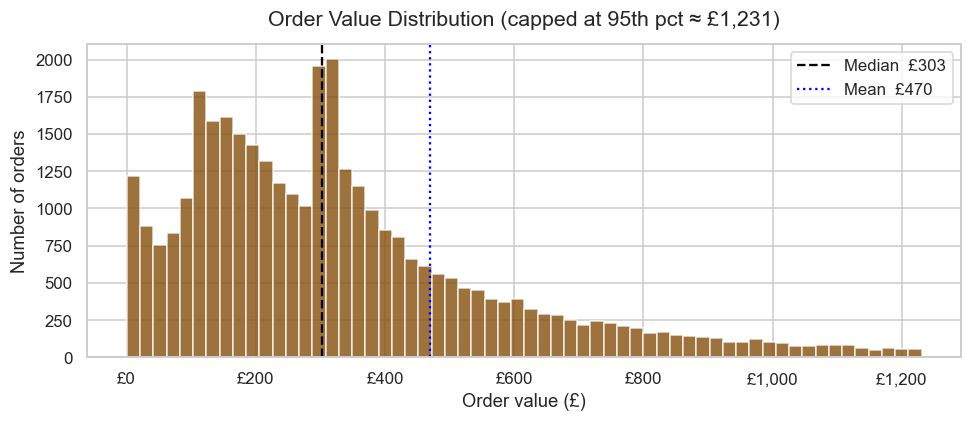

In [28]:
aov = df.groupby('Invoice')['TotalPrice'].sum()
cap_aov = aov.quantile(0.95)  # cap at 95th pct to hide extreme outliers in the chart

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(aov[aov <= cap_aov], bins=60, color=AMBER, alpha=0.8, edgecolor='white')

ax.axvline(aov.median(), color='black', linewidth=1.5, linestyle='--',
           label=f'Median  £{aov.median():.0f}')
ax.axvline(aov.mean(), color='blue', linewidth=1.5, linestyle=':',
           label=f'Mean  £{aov.mean():.0f}')

ax.set_title(f'Order Value Distribution (capped at 95th pct ≈ £{cap_aov:,.0f})',
             fontsize=14, pad=12)
ax.set_xlabel('Order value (£)')
ax.set_ylabel('Number of orders')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_05_aov.png', bbox_inches='tight')
plt.show()

In [34]:
aov[aov <= cap_aov].var()

np.float64(58887.54662387539)

## Cell 10 — Plot 6: Orders heatmap (Day × Hour)
When do customers buy? Useful for timing email campaigns and promotions.
Dark cells = lots of orders. Light cells = quiet periods.

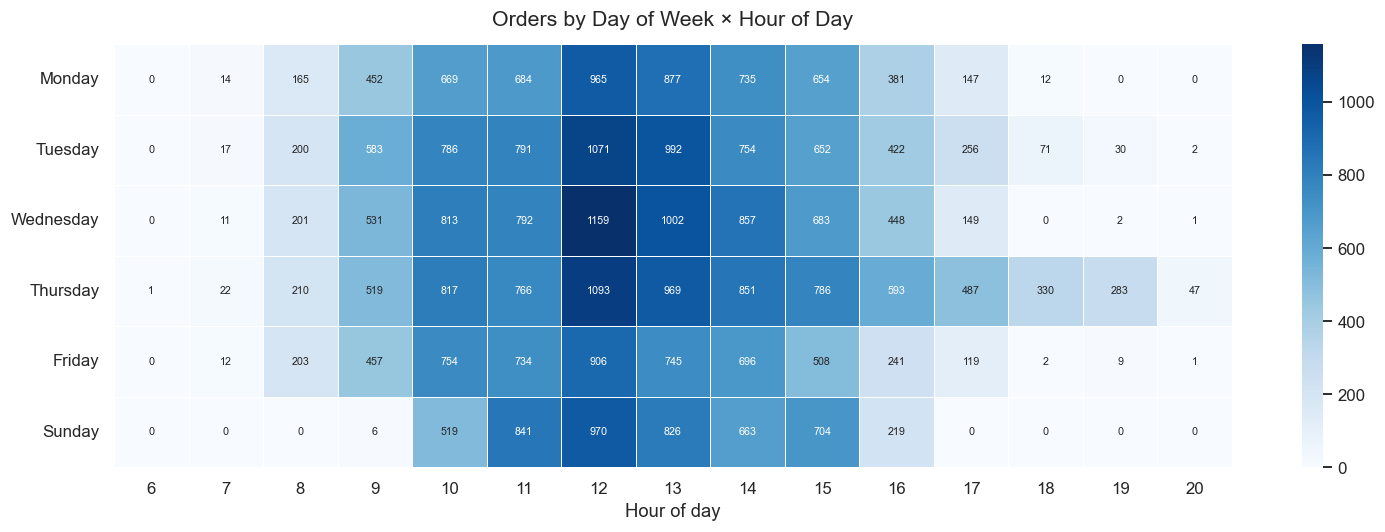

Observation: peak ordering is Tuesday-Thursday, 10am-3pm.
This is a B2B / wholesale dataset — weekend ordering is very low.


In [35]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
# Note: Saturday barely appears in this UK B2B dataset (businesses are closed)

pivot = (
    df.groupby(['DayOfWeek', 'Hour'])['Invoice']
      .nunique()
      .reset_index()
      .rename(columns={'Invoice': 'Orders'})
)
pivot_tbl = pivot.pivot(index='DayOfWeek', columns='Hour', values='Orders').fillna(0)
pivot_tbl = pivot_tbl.reindex([d for d in DAY_ORDER if d in pivot_tbl.index])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_tbl,
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Orders by Day of Week × Hour of Day', fontsize=14, pad=12)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_06_order_heatmap.png', bbox_inches='tight')
plt.show()

print('Observation: peak ordering is Tuesday-Thursday, 10am-3pm.')
print('This is a B2B / wholesale dataset — weekend ordering is very low.')

## Cell 11 — Plot 7: Customer frequency segments
A simple bar chart grouping customers by how many times they've ordered.
The 'bought only once' group is usually the largest — these are candidates for win-back campaigns.

In [39]:
freq_df = orders_per_customer.reset_index()
freq_df.columns = ['CustomerID', 'Orders']
freq_df

,CustomerID,Orders
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1
...,...,...
5873,18283,22
5874,18284,1
5875,18285,1
5876,18286,2


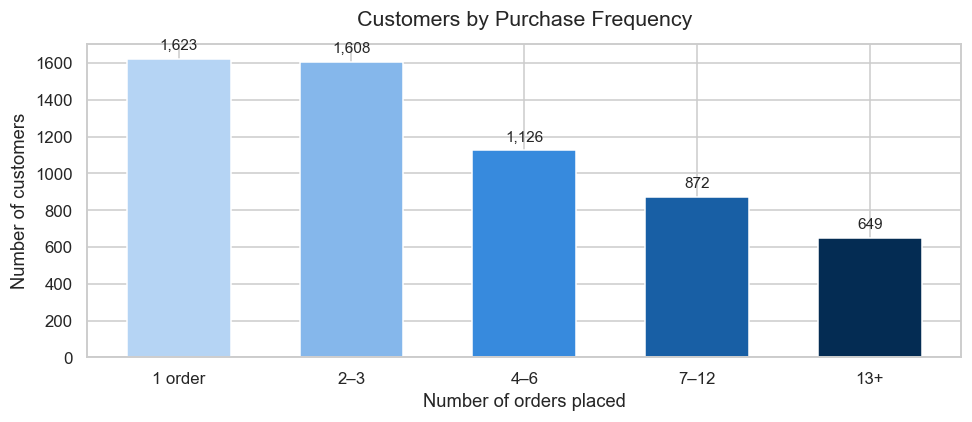

One-time buyers: 27.6% of all customers
These are the most important group to re-engage in Week-2 tasks.


In [40]:
freq_bins   = [0, 1, 3, 6, 12, float('inf')] #How did we choose these frequency bins?
freq_labels = ['1 order', '2–3', '4–6', '7–12', '13+'] 

freq_df = orders_per_customer.reset_index()
freq_df.columns = ['CustomerID', 'Orders']
freq_df['Segment'] = pd.cut(freq_df['Orders'], bins=freq_bins, labels=freq_labels)

seg_counts = freq_df['Segment'].value_counts().reindex(freq_labels)
colors = ['#B5D4F4', '#85B7EB', '#378ADD', '#185FA5', '#042C53']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(seg_counts.index, seg_counts.values,
              color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, labels=[f'{v:,}' for v in seg_counts.values],
             padding=4, fontsize=10)

ax.set_title('Customers by Purchase Frequency', fontsize=14, pad=12)
ax.set_xlabel('Number of orders placed')
ax.set_ylabel('Number of customers')

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_07_frequency_segments.png', bbox_inches='tight')
plt.show()

one_time_pct = seg_counts['1 order'] / seg_counts.sum() * 100
print(f'One-time buyers: {one_time_pct:.1f}% of all customers')
print('These are the most important group to re-engage in Week-2 tasks.')

## Cell 12 — Log everything to MLflow
MLflow records this EDA run so you always have a dated snapshot of your dataset stats.
You'll see this run at http://127.0.0.1:5000 after running `mlflow ui` in a terminal.

In [45]:
# Point MLflow at the mlruns/ folder inside your project root
#mlflow.set_tracking_uri(f'file:///{ROOT / "mlruns"}')
# Instead of file:///mlruns, point to a SQLite database file
mlflow.set_tracking_uri(f'sqlite:///{ROOT / "mlflow.db"}')

mlflow.set_experiment('customer_segmentation')

with mlflow.start_run(run_name='Week1_EDA'):

    # Log the dataset stats as 'params' (text values)
    mlflow.log_param('dataset',      'UCI Online Retail II')
    mlflow.log_param('date_start',   stats['date_start'])
    mlflow.log_param('date_end',     stats['date_end'])
    mlflow.log_param('cleaning',     'dropped nulls, cancellations, bad price/qty')

    # Log the key numbers as 'metrics' (numeric values you can chart over time)
    mlflow.log_metric('total_rows',         stats['total_rows'])
    mlflow.log_metric('unique_customers',   stats['unique_customers'])
    mlflow.log_metric('unique_invoices',    stats['unique_invoices'])
    mlflow.log_metric('unique_products',    stats['unique_products'])
    mlflow.log_metric('total_revenue_gbp',  stats['total_revenue_gbp'])
    mlflow.log_metric('median_order_value', stats['median_order_value'])

    # Log all 7 plots as artifacts (files attached to this run)
    for plot_file in RPT_DIR.glob('plot_0*.png'):
        mlflow.log_artifact(str(plot_file), artifact_path='eda_plots')

    run_id = mlflow.active_run().info.run_id

print(f'MLflow run logged. Run ID: {run_id}')
print()
print('To view it:')
print('  1. Open a new terminal')
print('  2. Activate venv: venv\\Scripts\\activate')
print('  3. Run: mlflow ui')
#mlflow ui --backend-store-uri sqlite:///mlflow.db
print('  4. Open: http://127.0.0.1:5000')

2026/06/09 18:14:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/09 18:14:34 INFO mlflow.store.db.utils: Updating database tables
2026/06/09 18:14:36 INFO mlflow.tracking.fluent: Experiment with name 'customer_segmentation' does not exist. Creating a new experiment.


MLflow run logged. Run ID: cbd99b7a11ab4e0596ad09341efff04b

To view it:
  1. Open a new terminal
  2. Activate venv: venv\Scripts\activate
  3. Run: mlflow ui
  4. Open: http://127.0.0.1:5000


## Cell 13 — Week 1 wrap-up
Make a final Git commit to save your work.

In [46]:
print('Week 1 complete! Here is what you built:')
print()
print('  ✓  Project folder + virtual environment')
print('  ✓  src/ingest.py — reproducible cleaning pipeline')
print('  ✓  data/clean_retail.csv — single source of truth')
print('  ✓  7 EDA plots saved to reports/')
print('  ✓  MLflow experiment run logged')
print()
print('Next step — open a terminal and commit:')
print('  git add .')
print('  git commit -m "Week 1: EDA complete, data pipeline, MLflow run"')
print()
print('Then move on to Week 2: RFM scoring + K-Means clustering.')

Week 1 complete! Here is what you built:

  ✓  Project folder + virtual environment
  ✓  src/ingest.py — reproducible cleaning pipeline
  ✓  data/clean_retail.csv — single source of truth
  ✓  7 EDA plots saved to reports/
  ✓  MLflow experiment run logged

Next step — open a terminal and commit:
  git add .
  git commit -m "Week 1: EDA complete, data pipeline, MLflow run"

Then move on to Week 2: RFM scoring + K-Means clustering.
